# Logistic Regression with Feature Engineering

In [22]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sys.path.append(str(Path("..").resolve()))
from transcript_preprocessing import get_stratified_kfold_splits, load_transcript_splits
from utils import compute_linguistic_features_for_column

DATA_PATH = Path("..") / "data" / "transcripts_cleaned.csv"
DEMENTIA_PATH = Path("..") / "data" / "dementia_data.csv"



## Load Data

Load the cleaned transcripts and check the class distribution


In [23]:
# Load data
transcript_df = pd.read_csv(DATA_PATH)
dementia_df = pd.read_csv(DEMENTIA_PATH)


print(f"Class distribution:")
print(transcript_df["Class"].value_counts())



Class distribution:
Class
HC          82
MCI         59
Dementia    16
Name: count, dtype: int64


## Feature Engineering

linguistic and demographic features

**Linguistic Features:**
| Feature | Description |
|---------|-------------|
| `token_count` | Total number of words |
| `type_count` | Number of unique words |
| `type_token_ratio` | Vocabulary diversity (unique/total) |
| `brunets_index` | Lexical richness measure |
| `ma_ttr` | Moving-average type-token ratio |
| `sentence_count` | Number of sentences |
| `average_words_per_sentence` | Mean sentence length |
| `filler_count` | Count of filler words (um, uh, er, etc.) |
| `found_fillers` | Binary: has any filler words? |
| `content_density` | Proportion of content words |
| `repetitions` | Number of repeated words |

**Demographic Features:**
| Feature | Description |
|---------|-------------|
| `Gender` | Encoded as 0/1 |
| `Age` | Patient age |
| `Converted-MMSE` | Mini-Mental State Exam score |


In [24]:
features_by_transcript = {}

for col in TRANSCRIPT_COLS:
    df = transcript_df.dropna(subset=[col]).copy()
    
    df_with_features = compute_linguistic_features_for_column(df, col)
    features_by_transcript[col] = df_with_features
    
    print(f"{col}: {len(df_with_features)} samples")

# demographic features
demo_df = dementia_df[["Record-ID", "Gender", "Age", "Converted-MMSE"]].copy()

# clean demographic data 
demo_df["Gender"] = demo_df["Gender"].map({"female": 0, "male": 1})
demo_df["Age"] = pd.to_numeric(demo_df["Age"].astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce")
demo_df["Converted-MMSE"] = pd.to_numeric(demo_df["Converted-MMSE"].astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce")

for col in TRANSCRIPT_COLS:
    features_by_transcript[col] = features_by_transcript[col].merge(
        demo_df, on="Record-ID", how="left"
    )


FEATURE_COLS = [
    # Linguistic features
    "token_count",
    "type_count", 
    "type_token_ratio",
    "ma_ttr",
    "brunets_index",
    "sentence_count",
    "average_words_per_sentence",
    "filler_count",
    "found_fillers",
    "content_density",
    "repetitions",
    # Demographic features
    "Gender",
    "Age",
    "Converted-MMSE",
]



Transcript_PFT: 157 samples
Transcript_CTD: 156 samples
Transcript_SFT: 152 samples


## Hyperparameter Search 

Different combinations of C (Regularization strength) and  class_weight


In [25]:
C_VALUES = [0.01, 0.1, 1.0, 10.0]
CLASS_WEIGHTS = [None, "balanced"]

#all configs to try
configs = []
for c in C_VALUES:
    for cw in CLASS_WEIGHTS:
        configs.append({"C": c, "class_weight": cw})



## Cross-Validation Function



In [26]:
def run_cv(df, transcript_col, config, n_splits=5, seed=42):
    """
    Run stratified k-fold cross-validation 
    """
    fold_results = []
    
    for fold_idx, train_idx, val_idx in get_stratified_kfold_splits(
        transcript_df=df,
        transcript_col=transcript_col,
        label_col="Label",
        n_splits=n_splits,
        seed=seed,
    ):

        X_train = df.iloc[train_idx][FEATURE_COLS].values
        y_train = df.iloc[train_idx]["Label"].values
        X_val = df.iloc[val_idx][FEATURE_COLS].values
        y_val = df.iloc[val_idx]["Label"].values
        
        X_train = np.nan_to_num(X_train, nan=0.0)
        X_val = np.nan_to_num(X_val, nan=0.0)
        
        # Scale features 
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        
        # Train
        model = LogisticRegression(
            C=config["C"],
            class_weight=config["class_weight"],
            max_iter=1000,
            random_state=seed,
        )
        model.fit(X_train, y_train)
        
    
        y_pred = model.predict(X_val)
        
        fold_results.append({
            "accuracy": accuracy_score(y_val, y_pred),
            "macro_f1": f1_score(y_val, y_pred, average="macro", zero_division=0),
        })
    
    # Average across folds
    return {
        "mean_accuracy": np.mean([r["accuracy"] for r in fold_results]),
        "mean_macro_f1": np.mean([r["macro_f1"] for r in fold_results]),
    }




## Run Grid Search

Try all hyperparameter combinations for each transcript type and find the best one.


In [27]:
# Run grid search for all transcript types
all_results = []
best_configs = {}

for transcript_col in TRANSCRIPT_COLS:
    df = features_by_transcript[transcript_col]
    print(f"\n{transcript_col} ({len(df)} samples)")
    
    best_f1 = 0
    best_config = None
    
    for config in configs:
        results = run_cv(df, transcript_col, config)
        
        all_results.append({
            "transcript": transcript_col,
            "C": config["C"],
            "class_weight": config["class_weight"],
            **results
        })
        
        # Track best config for this transcript type
        if results["mean_macro_f1"] > best_f1:
            best_f1 = results["mean_macro_f1"]
            best_config = config.copy()
    
    best_configs[transcript_col] = best_config
    print(f"Best: C={best_config['C']}, class_weight={best_config['class_weight']}")
    print(f"Macro F1: {best_f1:.4f}")


results_df = pd.DataFrame(all_results)




Transcript_PFT (157 samples)
Best: C=10.0, class_weight=None
Macro F1: 0.4054

Transcript_CTD (156 samples)
Best: C=0.1, class_weight=None
Macro F1: 0.4305

Transcript_SFT (152 samples)
Best: C=0.1, class_weight=balanced
Macro F1: 0.4079


In [28]:
# top 3 configs per transcript type
results_df.sort_values(
    ["transcript", "mean_macro_f1"], 
    ascending=[True, False]
).groupby("transcript").head(3)


,transcript,C,class_weight,mean_accuracy,mean_macro_f1
10,Transcript_CTD,0.10,None,0.646774,0.430488
14,Transcript_CTD,10.00,None,0.564113,0.419072
8,Transcript_CTD,0.01,None,0.633669,0.404653
6,Transcript_PFT,10.00,None,0.579234,0.405351
4,Transcript_PFT,1.00,None,0.572782,0.392045
3,Transcript_PFT,0.10,balanced,0.476613,0.389784
19,Transcript_SFT,0.10,balanced,0.480430,0.407854
23,Transcript_SFT,10.00,balanced,0.466667,0.406816
22,Transcript_SFT,10.00,None,0.526022,0.398430


## Evaluate Best Models

Generate confusion matrices and classification reports using the best hyperparameters for each transcript type.


In [29]:
CLASS_NAMES = ["HC", "MCI", "Dementia"]

def evaluate_best_model(df, transcript_col, config, n_splits=5, seed=42):
    """
    Run CV with best config and collect all predictions for confusion matrix.
    """
    all_y_true = []
    all_y_pred = []
    
    for fold_idx, train_idx, val_idx in get_stratified_kfold_splits(
        transcript_df=df, transcript_col=transcript_col,
        label_col="Label", n_splits=n_splits, seed=seed,
    ):
        X_train = np.nan_to_num(df.iloc[train_idx][FEATURE_COLS].values, nan=0.0)
        y_train = df.iloc[train_idx]["Label"].values
        X_val = np.nan_to_num(df.iloc[val_idx][FEATURE_COLS].values, nan=0.0)
        y_val = df.iloc[val_idx]["Label"].values
        
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        
        model = LogisticRegression(
            C=config["C"], class_weight=config["class_weight"],
            max_iter=1000, random_state=seed
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)
    
    return np.array(all_y_true), np.array(all_y_pred)



### Confusion Matrices and Classification Reports


Transcript_PFT
Best config: C=10.0, class_weight=None


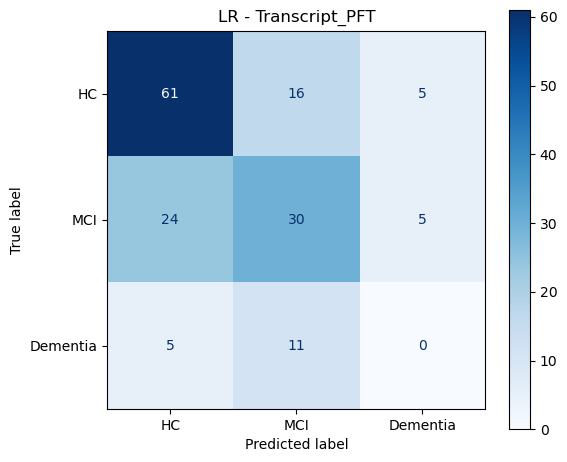


Classification Report:
              precision    recall  f1-score   support

          HC       0.68      0.74      0.71        82
         MCI       0.53      0.51      0.52        59
    Dementia       0.00      0.00      0.00        16

    accuracy                           0.58       157
   macro avg       0.40      0.42      0.41       157
weighted avg       0.55      0.58      0.56       157

Transcript_CTD
Best config: C=0.1, class_weight=None


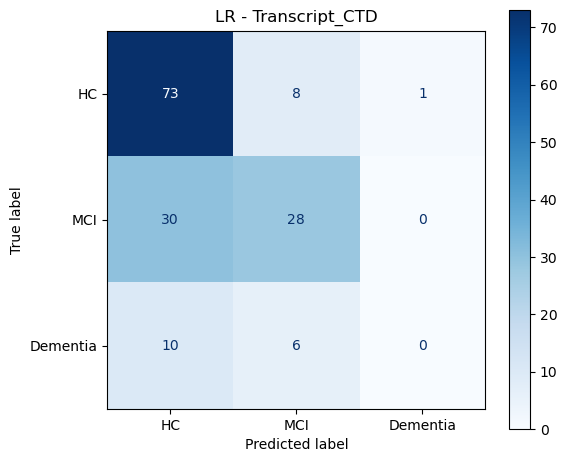


Classification Report:
              precision    recall  f1-score   support

          HC       0.65      0.89      0.75        82
         MCI       0.67      0.48      0.56        58
    Dementia       0.00      0.00      0.00        16

    accuracy                           0.65       156
   macro avg       0.44      0.46      0.44       156
weighted avg       0.59      0.65      0.60       156

Transcript_SFT
Best config: C=0.1, class_weight=balanced


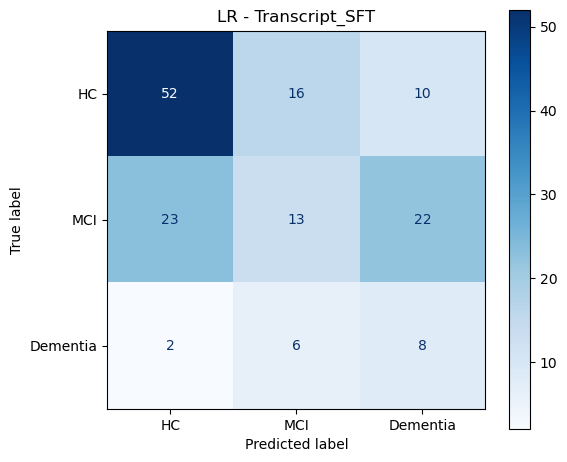


Classification Report:
              precision    recall  f1-score   support

          HC       0.68      0.67      0.67        78
         MCI       0.37      0.22      0.28        58
    Dementia       0.20      0.50      0.29        16

    accuracy                           0.48       152
   macro avg       0.42      0.46      0.41       152
weighted avg       0.51      0.48      0.48       152



In [30]:
# best model for each transcript type
for transcript_col in TRANSCRIPT_COLS:
    df = features_by_transcript[transcript_col]
    config = best_configs[transcript_col]
    
    print(f"{transcript_col}")
    print(f"Best config: C={config['C']}, class_weight={config['class_weight']}")
 
    
    y_true, y_pred = evaluate_best_model(df, transcript_col, config)
    

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"LR - {transcript_col}")
    plt.tight_layout()
    plt.savefig(f"results/lr_cm_{transcript_col}.png", dpi=150)
    plt.show()
    

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


## Feature Importance

Features most important for classification

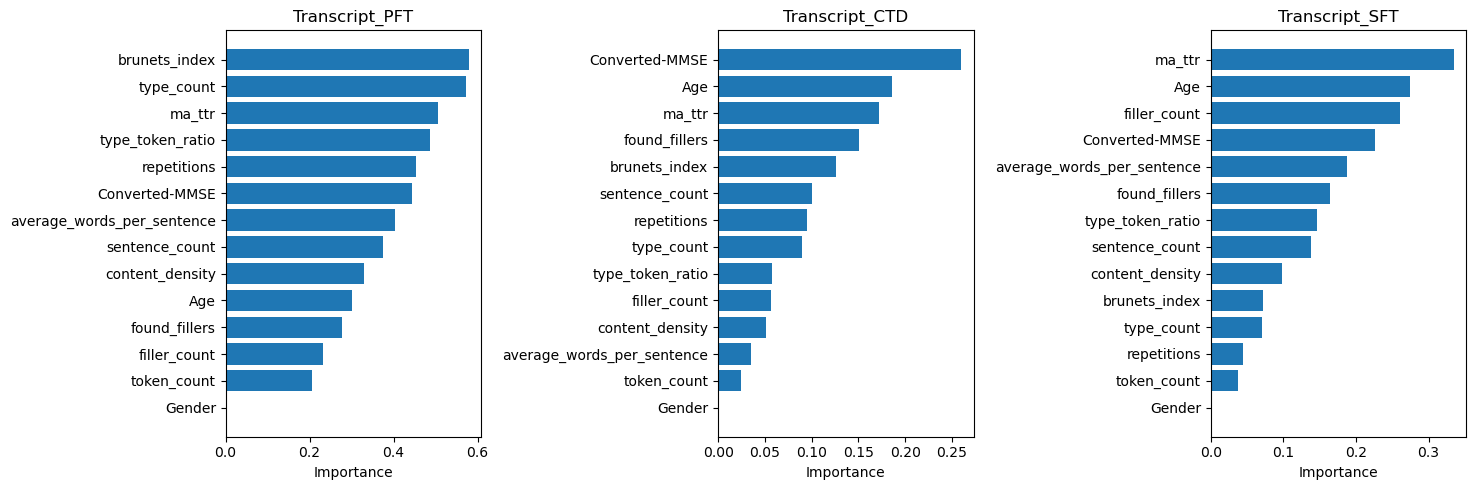

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, transcript_col in zip(axes, TRANSCRIPT_COLS):
    df = features_by_transcript[transcript_col]
    config = best_configs[transcript_col]
    
    X = np.nan_to_num(df[FEATURE_COLS].values, nan=0.0)
    y = df["Label"].values
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = LogisticRegression(
        C=config["C"], class_weight=config["class_weight"],
        max_iter=1000, random_state=42
    )
    model.fit(X_scaled, y)
    
    # Average absolute coefficients across classes
    importance = np.abs(model.coef_).mean(axis=0)
    sorted_idx = np.argsort(importance)
    
    ax.barh([FEATURE_COLS[i] for i in sorted_idx], importance[sorted_idx])
    ax.set_xlabel("Importance")
    ax.set_title(transcript_col)

plt.tight_layout()
plt.savefig("results/lr_feature_importance.png", dpi=150)
plt.show()


## Summary

Compare LR with Feature Engineering results across transcript types.



Best Results per Transcript Type:
    transcript    C class_weight  mean_accuracy  mean_macro_f1
Transcript_CTD  0.1         None       0.646774       0.430488
Transcript_SFT  0.1     balanced       0.480430       0.407854
Transcript_PFT 10.0         None       0.579234       0.405351


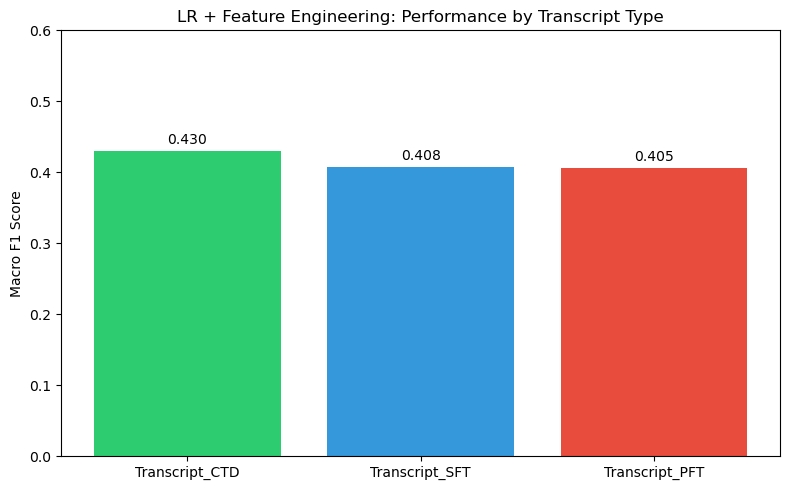


Best transcript type: Transcript_CTD
Best macro F1: 0.4305


In [32]:
summary = results_df.loc[
    results_df.groupby("transcript")["mean_macro_f1"].idxmax()
][["transcript", "C", "class_weight", "mean_accuracy", "mean_macro_f1"]]

summary = summary.sort_values("mean_macro_f1", ascending=False)
print("\nBest Results per Transcript Type:")
print(summary.to_string(index=False))


fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(summary))
colors = ["#2ecc71", "#3498db", "#e74c3c"]
ax.bar(x, summary["mean_macro_f1"], color=colors)
ax.set_xticks(x)
ax.set_xticklabels(summary["transcript"])
ax.set_ylabel("Macro F1 Score")
ax.set_title("LR + Feature Engineering: Performance by Transcript Type")
ax.set_ylim(0, 0.6)
for i, v in enumerate(summary["mean_macro_f1"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig("results/lr_feature_eng_comparison.png", dpi=150)
plt.show()

print(f"\nBest transcript type: {summary.iloc[0]['transcript']}")
print(f"Best macro F1: {summary.iloc[0]['mean_macro_f1']:.4f}")


## LR with TF-IDF and Feature Engineering




### Hyperparameter Grid



In [ ]:
param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "tfidf__max_df": [0.9, 1.0],
    "tfidf__max_features": [2000, 5000],
    "clf__C": [0.1, 1.0, 10.0],
    "clf__solver": ["lbfgs", "newton-cg"],
    "clf__class_weight": [None, "balanced"],
}

total_configs = 1
for v in param_grid.values():
    total_configs *= len(v)


### Grid Search Function


In [ ]:
def run_combined_grid_search(df, transcript_col, param_grid, n_splits=5, seed=42):
    """
    Run grid search combining TF-IDF + feature-engineered features
    """
    # Get texts from original transcript_df using Record-ID
    transcript_texts = transcript_df.set_index("Record-ID")[transcript_col].fillna("").astype(str)
    texts = df["Record-ID"].map(transcript_texts).fillna("").astype(str).values
    
    # fe features
    engineered_features = np.nan_to_num(df[FEATURE_COLS].values, nan=0.0)
    labels = df["Label"].values
    
   
    cv_splits = []
    for fold_idx, train_idx, val_idx in get_stratified_kfold_splits(
        transcript_df=df,
        transcript_col=transcript_col,
        label_col="Label",
        n_splits=n_splits,
        seed=seed,
    ):
        cv_splits.append((train_idx, val_idx))
    
    # manual grid search to combine features 
    from itertools import product
    
    results_list = []
    best_score = -1
    best_params = None
    
    for params in product(*param_grid.values()):
        param_dict = dict(zip(param_grid.keys(), params))
        
        
        tfidf = TfidfVectorizer(
            ngram_range=param_dict["tfidf__ngram_range"],
            min_df=param_dict["tfidf__min_df"],
            max_df=param_dict["tfidf__max_df"],
            max_features=param_dict["tfidf__max_features"],
        )
        
        fold_scores = []
        
        for train_idx, val_idx in cv_splits:
            X_train_tfidf = tfidf.fit_transform(texts[train_idx])
            X_val_tfidf = tfidf.transform(texts[val_idx])
            
            X_train_fe = engineered_features[train_idx]
            X_val_fe = engineered_features[val_idx]
            
            scaler = StandardScaler()
            X_train_fe_scaled = scaler.fit_transform(X_train_fe)
            X_val_fe_scaled = scaler.transform(X_val_fe)
            
            # combine tfidf and fe features
            X_train_combined = np.hstack([X_train_tfidf.toarray(), X_train_fe_scaled])
            X_val_combined = np.hstack([X_val_tfidf.toarray(), X_val_fe_scaled])
            
            y_train = labels[train_idx]
            y_val = labels[val_idx]
            

            model = LogisticRegression(
                C=param_dict["clf__C"],
                solver=param_dict["clf__solver"],
                class_weight=param_dict["clf__class_weight"],
                max_iter=1000,
                random_state=seed,
            )
            model.fit(X_train_combined, y_train)
            y_pred = model.predict(X_val_combined)
            
            fold_scores.append(f1_score(y_val, y_pred, average="macro", zero_division=0))
        
        mean_score = np.mean(fold_scores)
        results_list.append({**param_dict, "score": mean_score})
        
        if mean_score > best_score:
            best_score = mean_score
            best_params = param_dict
    
    # mock object for compatibility
    class MockGridSearch:
        def __init__(self, best_params, best_score):
            self.best_params_ = best_params
            self.best_score_ = best_score
    
    return MockGridSearch(best_params, best_score), results_list



### Run Grid Search


In [35]:
combined_results = []

for transcript_col in TRANSCRIPT_COLS:
    df = features_by_transcript[transcript_col]
    print(f"{transcript_col} ({len(df)} samples)")
    
    grid_search, all_results = run_combined_grid_search(df, transcript_col, param_grid)
    
    print(f"\nBest params: {grid_search.best_params_}")
    print(f"Best CV score (macro F1): {grid_search.best_score_:.4f}")
    
    combined_results.append({
        "transcript": transcript_col,
        **grid_search.best_params_,
        "best_score": grid_search.best_score_,
    })

combined_results_df = pd.DataFrame(combined_results)



Transcript_PFT (157 samples)

Best params: {'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 1, 'tfidf__max_df': 1.0, 'tfidf__max_features': 2000, 'clf__C': 10.0}
Best CV score (macro F1): 0.4170
Transcript_CTD (156 samples)

Best params: {'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 1, 'tfidf__max_df': 0.9, 'tfidf__max_features': 2000, 'clf__C': 10.0}
Best CV score (macro F1): 0.4445
Transcript_SFT (152 samples)

Best params: {'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 1, 'tfidf__max_df': 0.9, 'tfidf__max_features': 2000, 'clf__C': 10.0}
Best CV score (macro F1): 0.4457


### Evaluate Best Models


Transcript_PFT
Best params: C=10.0, ngram=(1, 2)


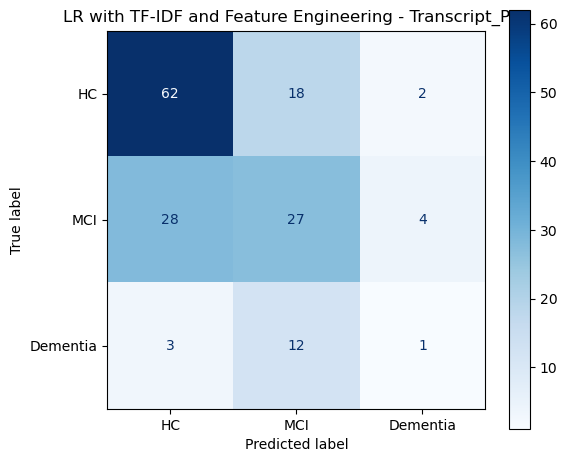


Classification Report:
              precision    recall  f1-score   support

          HC       0.67      0.76      0.71        82
         MCI       0.47      0.46      0.47        59
    Dementia       0.14      0.06      0.09        16

    accuracy                           0.57       157
   macro avg       0.43      0.43      0.42       157
weighted avg       0.54      0.57      0.55       157

Transcript_CTD
Best params: C=10.0, ngram=(1, 1)


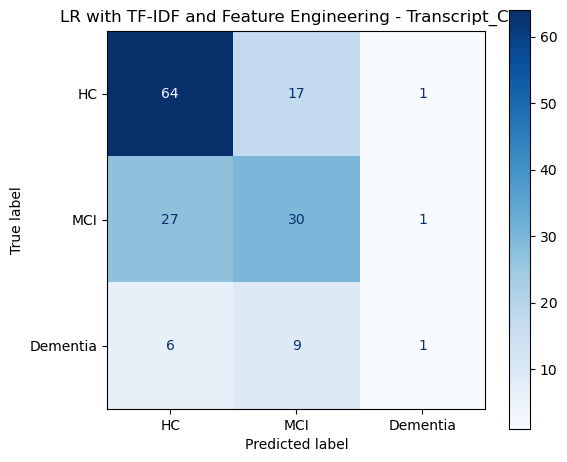


Classification Report:
              precision    recall  f1-score   support

          HC       0.66      0.78      0.72        82
         MCI       0.54      0.52      0.53        58
    Dementia       0.33      0.06      0.11        16

    accuracy                           0.61       156
   macro avg       0.51      0.45      0.45       156
weighted avg       0.58      0.61      0.58       156

Transcript_SFT
Best params: C=10.0, ngram=(1, 1)


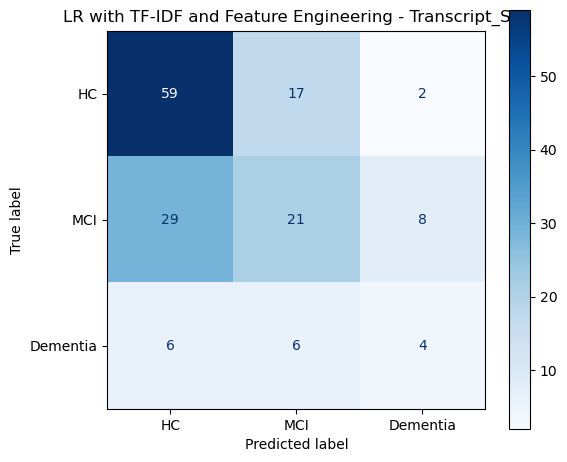


Classification Report:
              precision    recall  f1-score   support

          HC       0.63      0.76      0.69        78
         MCI       0.48      0.36      0.41        58
    Dementia       0.29      0.25      0.27        16

    accuracy                           0.55       152
   macro avg       0.46      0.46      0.45       152
weighted avg       0.53      0.55      0.54       152



In [ ]:
def evaluate_combined_model(df, transcript_col, best_params, n_splits=5, seed=42):
    """
    Run CV with best hyperparameters and collect predictions
    """
    all_y_true = []
    all_y_pred = []
    
    # Get texts from original transcript_df
    transcript_texts = transcript_df.set_index("Record-ID")[transcript_col].fillna("").astype(str)
    texts = df["Record-ID"].map(transcript_texts).fillna("").astype(str).values
    
    engineered_features = np.nan_to_num(df[FEATURE_COLS].values, nan=0.0)
    labels = df["Label"].values
    
    for fold_idx, train_idx, val_idx in get_stratified_kfold_splits(
        transcript_df=df,
        transcript_col=transcript_col,
        label_col="Label",
        n_splits=n_splits,
        seed=seed,
    ):
        tfidf = TfidfVectorizer(
            ngram_range=best_params["tfidf__ngram_range"],
            min_df=best_params["tfidf__min_df"],
            max_df=best_params["tfidf__max_df"],
            max_features=best_params["tfidf__max_features"],
        )
        X_train_tfidf = tfidf.fit_transform(texts[train_idx])
        X_val_tfidf = tfidf.transform(texts[val_idx])
        
        X_train_fe = engineered_features[train_idx]
        X_val_fe = engineered_features[val_idx]
        
        scaler = StandardScaler()
        X_train_fe_scaled = scaler.fit_transform(X_train_fe)
        X_val_fe_scaled = scaler.transform(X_val_fe)
        
        X_train_combined = np.hstack([X_train_tfidf.toarray(), X_train_fe_scaled])
        X_val_combined = np.hstack([X_val_tfidf.toarray(), X_val_fe_scaled])
        
        y_train = labels[train_idx]
        y_val = labels[val_idx]
        
        model = LogisticRegression(
            C=best_params["clf__C"],
            solver=best_params["clf__solver"],
            class_weight=best_params["clf__class_weight"],
            max_iter=1000,
            random_state=seed,
        )
        model.fit(X_train_combined, y_train)
        y_pred = model.predict(X_val_combined)
        
        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)
    
    return np.array(all_y_true), np.array(all_y_pred)

# Evaluate best models
for transcript_col in TRANSCRIPT_COLS:
    df = features_by_transcript[transcript_col]
    best_row = combined_results_df[combined_results_df['transcript']==transcript_col].iloc[0]
    best_params = {
        "tfidf__ngram_range": best_row["tfidf__ngram_range"],
        "tfidf__min_df": best_row["tfidf__min_df"],
        "tfidf__max_df": best_row["tfidf__max_df"],
        "tfidf__max_features": best_row["tfidf__max_features"],
        "clf__C": best_row["clf__C"],
        "clf__solver": best_row["clf__solver"],
        "clf__class_weight": best_row["clf__class_weight"],
    }
    
    print(f"{transcript_col}")
    print(f"Best params: C={best_row['clf__C']}, solver={best_row['clf__solver']}, class_weight={best_row['clf__class_weight']}, ngram={best_row['tfidf__ngram_range']}")
    
    y_true, y_pred = evaluate_combined_model(df, transcript_col, best_params)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"LR with TF-IDF and Feature Engineering - {transcript_col}")
    plt.tight_layout()
    plt.savefig(f"results_2/lr_combined_cm_{transcript_col}.png", dpi=150)
    plt.show()
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


### Summary



Best Results per Transcript Type:
    transcript tfidf__ngram_range  tfidf__min_df  tfidf__max_df  tfidf__max_features  clf__C  best_score
Transcript_SFT             (1, 1)              1            0.9                 2000    10.0    0.445712
Transcript_CTD             (1, 1)              1            0.9                 2000    10.0    0.444462
Transcript_PFT             (1, 2)              1            1.0                 2000    10.0    0.416954


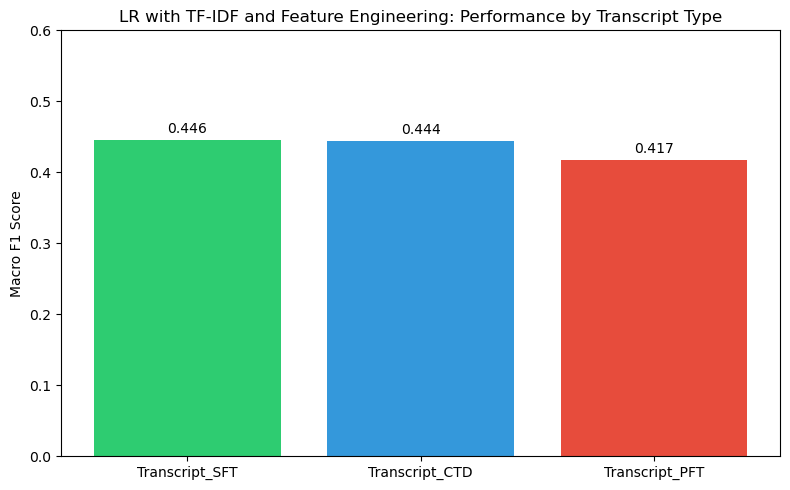


Best transcript type: Transcript_SFT
Best macro F1: 0.4457


In [37]:
summary = combined_results_df.sort_values("best_score", ascending=False)
print("\nBest Results per Transcript Type:")
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(summary))
colors = ["#2ecc71", "#3498db", "#e74c3c"]
ax.bar(x, summary["best_score"], color=colors)
ax.set_xticks(x)
ax.set_xticklabels(summary["transcript"])
ax.set_ylabel("Macro F1 Score")
ax.set_title("LR with TF-IDF and Feature Engineering: Performance by Transcript Type")
ax.set_ylim(0, 0.6)
for i, v in enumerate(summary["best_score"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig("results_2/lr_combined_comparison.png", dpi=150)
plt.show()

print(f"\nBest transcript type: {summary.iloc[0]['transcript']}")
print(f"Best macro F1: {summary.iloc[0]['best_score']:.4f}")


### Save Results


In [38]:
# Save results
combined_results_df.to_csv("results_2/lr_combined_grid_search.csv", index=False)
summary.to_csv("results_2/lr_combined_best.csv", index=False)
results_df.to_csv("results/lr_feature_eng_grid_search.csv", index=False)
summary.to_csv("results/lr_feature_eng_best.csv", index=False)
